# Integrated scGPT Perturbation Pipeline (Fixed Vocab & Data Leakage)

In [1]:
import sys
import os
import time
import copy
import random
import json
import warnings
from pathlib import Path
from typing import Iterable, List, Tuple, Dict, Union, Optional

import numpy as np
import torch
import scanpy as sc
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

import scgpt as scg
from scgpt.model import TransformerGenerator
from scgpt.tokenizer import GeneVocab
from scgpt.loss import masked_mse_loss
from scgpt.utils import set_seed, map_raw_id_to_vocab_id

matplotlib.rcParams["savefig.transparent"] = False
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/conda_envs/scgpt/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/conda_envs/scgpt/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/conda_envs/scgpt/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/conda_envs/scgpt/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warn

In [2]:
def setup_environment(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    sc.settings.seed = seed
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set as {seed}")

setup_environment(42)
print(f"✅ Research Environment Initialized on {device}")

Random seed set as 42
✅ Research Environment Initialized on cuda


In [3]:
# --- Settings & Hyperparameters ---
data_name = "norman"
model_dir = "../../model_checkpoints/scGPT_human"
load_model = model_dir

pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
pad_value = 0
pert_pad_id = 0
include_zero_gene = "all"
max_seq_len = 1536

epochs = 15
lr = 1e-4
batch_size = 384 
eval_batch_size = 384
schedule_interval = 1
early_stop = 10
amp = True

embsize = 128
d_hid = 512
nlayers = 4
nhead = 4
n_layers_cls = 3
dropout = 0.2
use_fast_transformer = False

# Note: MLM=True simply activates the expression prediction head.
MLM = True
CLS = False
CCE = False
MVC = False
ECS = False

log_interval = 50
perts_to_plot = ["SAMD1+ZBTB1"] 

save_dir = Path(f"./save/dev_perturb_{data_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"saving to {save_dir}")

logger = scg.logger
scg.utils.add_file_handler(logger, save_dir / "run.log")
# --- 1. Data Preparation & FIXING VOCABULARY ---
adata = sc.read_h5ad("../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad")

adata.obs['split'] = adata.obs['gears_split']
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print(f"🔍 DIAGNOSTIC BEFORE VOCAB FIX: {adata.var_names[:5].tolist()}")

saving to save/dev_perturb_norman-Mar05-10-53
🔍 DIAGNOSTIC BEFORE VOCAB FIX: ['ENSG00000239945', 'ENSG00000223764', 'ENSG00000187634', 'ENSG00000187642', 'ENSG00000188290']


In [4]:
# 🚨 FIX 1: VOCABULARY MISMATCH
# Swap Ensembl IDs for Gene Symbols so scGPT recognizes them
if 'gene_name' in adata.var:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()

print(f"✅ DIAGNOSTIC AFTER VOCAB FIX: {adata.var_names[:5].tolist()}")

✅ DIAGNOSTIC AFTER VOCAB FIX: ['RP11-34P13.8', 'RP11-54O7.3', 'SAMD11', 'PERM1', 'HES4']


In [5]:
# Extract perturbed genes before HVG calculation
perturbed_genes = set()
for condition in adata.obs['condition'].unique():
    if condition != 'ctrl':
        for p in condition.split('+'):
            if p != 'ctrl':
                perturbed_genes.add(p)

sc.pp.highly_variable_genes(adata, n_top_genes=1200, flavor='seurat', subset=False)

for gene in perturbed_genes:
    if gene in adata.var_names:
        adata.var.loc[gene, 'highly_variable'] = True

adata = adata[:, adata.var.highly_variable].copy()

In [6]:
# 🚨 FIX 2: GLOBAL CONTROL POOL FOR DATA LEAKAGE
# Extract all control cells globally to sample from during training/eval
ctrl_adata = adata[adata.obs['condition'] == 'ctrl'].copy()
global_ctrl_X = ctrl_adata.X.toarray() if hasattr(ctrl_adata.X, "toarray") else ctrl_adata.X

class scGPTPerturbDataset(Dataset):
    def __init__(self, adata, ctrl_X, split="train"):
        self.adata = adata[adata.obs['split'] == split].copy()
        
        if hasattr(self.adata.X, "toarray"):
            self.X = self.adata.X.toarray()
        else:
            self.X = self.adata.X
            
        self.conditions = self.adata.obs['condition'].values
        self.gene_names = self.adata.var_names.tolist()
        self.gene_to_idx = {gene: i for i, gene in enumerate(self.gene_names)}
        self.ctrl_X = ctrl_X # Pass the unperturbed pool

    def __len__(self):
        return len(self.adata)

    def __getitem__(self, idx):
        # Target is the true perturbed state
        target_expr = torch.tensor(self.X[idx], dtype=torch.float32)
        condition = self.conditions[idx]
        
        pert_flags = torch.zeros(len(self.gene_names), dtype=torch.long)
        if condition != "ctrl":
            for p in condition.split('+'):
                if p != "ctrl" and p in self.gene_to_idx:
                    pert_flags[self.gene_to_idx[p]] = 1
                    
        # 🚨 FIX 2 (CONT): Sample a random baseline control cell as input
        random_ctrl_idx = np.random.randint(0, len(self.ctrl_X))
        ori_expr = torch.tensor(self.ctrl_X[random_ctrl_idx], dtype=torch.float32)
        
        return ori_expr, pert_flags, target_expr, condition

train_dataset = scGPTPerturbDataset(adata, global_ctrl_X, split="train")
val_dataset = scGPTPerturbDataset(adata, global_ctrl_X, split="val")
test_dataset = scGPTPerturbDataset(adata, global_ctrl_X, split="test")

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=eval_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=eval_batch_size, shuffle=False)

# 🔍 DIAGNOSTIC: Prove Data Leakage is fixed
sample_ori, sample_pert, sample_target, _ = train_dataset[0]
is_identical = torch.all(sample_ori == sample_target).item()
print(f"✅ DATA LEAKAGE CHECK: Are Input and Target identical? -> {is_identical}")

✅ DATA LEAKAGE CHECK: Are Input and Target identical? -> False


In [7]:
# --- 2. Model Weight & Vocab Initialization ---
load_param_prefixs = ["encoder", "value_encoder", "transformer_encoder"]
model_file = Path(load_model) / "best_model.pt"
vocab_file = Path(load_model) / "vocab.json"

vocab = GeneVocab.from_file(vocab_file)
for s in special_tokens:
    if s not in vocab:
        vocab.append_token(s)

adata.var["id_in_vocab"] = [
    1 if gene in vocab else -1 for gene in adata.var_names
]
gene_ids_in_vocab = np.array(adata.var["id_in_vocab"])

# 🔍 THIS SHOULD NOW SAY ~1100+/1200 MATCHED
logger.info(
    f"match {np.sum(gene_ids_in_vocab >= 0)}/{len(gene_ids_in_vocab)} genes "
    f"in vocabulary of size {len(vocab)}."
)

genes = adata.var_names.tolist()
gene_ids = np.array(
    [vocab[gene] if gene in vocab else vocab["<pad>"] for gene in genes], dtype=int
)
n_genes = len(genes)

ntokens = len(vocab)
model = TransformerGenerator(
    ntokens, embsize, nhead, d_hid, nlayers,
    nlayers_cls=n_layers_cls, n_cls=1, vocab=vocab, dropout=dropout,
    pad_token=pad_token, pad_value=pad_value, pert_pad_id=pert_pad_id,
    use_fast_transformer=use_fast_transformer,
)

pretrained_dict = torch.load(model_file)
model_dict = model.state_dict()
filtered_dict = {
    k: v for k, v in pretrained_dict.items()
    if any(k.startswith(prefix) for prefix in load_param_prefixs)
    and k in model_dict and v.shape == model_dict[k].shape
}

missing_keys, unexpected_keys = model.load_state_dict(filtered_dict, strict=False)
logger.info(f"Loaded {len(filtered_dict)} parameters.")
model.to(device)
# --- 3. Pure PyTorch Training & Evaluation Functions ---
criterion = masked_mse_loss
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, schedule_interval, gamma=0.9)
scaler = torch.cuda.amp.GradScaler(enabled=amp)

def train(model: nn.Module, train_loader: DataLoader) -> None:
    model.train()
    total_loss, total_mse = 0.0, 0.0
    start_time = time.time()
    num_batches = len(train_loader)

    for batch, (ori_expr, pert_flags, target_expr, _) in enumerate(train_loader):
        batch_size = ori_expr.size(0)
        
        ori_gene_values = ori_expr.to(device)
        pert_flags = pert_flags.to(device)
        target_gene_values = target_expr.to(device)

        if include_zero_gene == "all":
            input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
        else:
            input_gene_ids = ori_gene_values.nonzero()[:, 1].flatten().unique().sort()[0]

        if len(input_gene_ids) > max_seq_len:
            input_gene_ids = torch.randperm(len(input_gene_ids), device=device)[:max_seq_len]
            
        input_values = ori_gene_values[:, input_gene_ids]
        input_pert_flags = pert_flags[:, input_gene_ids]
        target_values = target_gene_values[:, input_gene_ids]
        
        mapped_input_gene_ids = map_raw_id_to_vocab_id(input_gene_ids, gene_ids).repeat(batch_size, 1)
        mapped_input_gene_ids = mapped_input_gene_ids.to(device)
        src_key_padding_mask = torch.zeros_like(input_values, dtype=torch.bool, device=device)

        with torch.cuda.amp.autocast(enabled=amp):
            output_dict = model(
                mapped_input_gene_ids, input_values, input_pert_flags,
                src_key_padding_mask=src_key_padding_mask,
                CLS=CLS, CCE=CCE, MVC=MVC, ECS=ECS,
            )
            output_values = output_dict["mlm_output"]
            
            # NOTE: ones_like is CORRECT here. We are doing full state forecasting, not masking out 15%.
            masked_positions = torch.ones_like(input_values, dtype=torch.bool)
            loss = loss_mse = criterion(output_values, target_values, masked_positions)

        model.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_mse += loss_mse.item()
        
        if batch % log_interval == 0 and batch > 0:
            cur_lr = scheduler.get_last_lr()[0]
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss, cur_mse = total_loss / log_interval, total_mse / log_interval
            logger.info(
                f"| batch {batch:3d}/{num_batches:3d} | "
                f"lr {cur_lr:05.4f} | ms/batch {ms_per_batch:5.2f} | "
                f"loss {cur_loss:5.2f} | mse {cur_mse:5.2f} |"
            )
            total_loss, total_mse = 0, 0
            start_time = time.time()

def eval_perturb(loader: DataLoader, model: TransformerGenerator, device: torch.device) -> Dict:
    model.eval()
    pert_cat, pred, truth = [], [], []
    
    input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
    mapped_input_gene_ids_base = map_raw_id_to_vocab_id(input_gene_ids, gene_ids).to(device)

    with torch.no_grad():
        for ori_expr, pert_flags, target_expr, conditions in loader:
            batch_size = ori_expr.size(0)
            
            input_values = ori_expr.to(device)
            input_pert_flags = pert_flags.to(device)
            target_values = target_expr.to(device)
            
            mapped_input_gene_ids = mapped_input_gene_ids_base.repeat(batch_size, 1)
            src_key_padding_mask = torch.zeros_like(input_values, dtype=torch.bool, device=device)

            with torch.cuda.amp.autocast(enabled=amp):
                output_dict = model(
                    mapped_input_gene_ids, input_values, input_pert_flags,
                    src_key_padding_mask=src_key_padding_mask,
                    CLS=CLS, CCE=CCE, MVC=MVC, ECS=ECS,
                )
                output_values = output_dict["mlm_output"]
                
            pert_cat.extend(conditions)
            pred.extend(output_values.cpu())
            truth.extend(target_values.cpu())

    return {
        "pert_cat": np.array(pert_cat),
        "pred": torch.stack(pred).numpy().astype(np.float64),
        "truth": torch.stack(truth).numpy().astype(np.float64),
    }

scGPT - INFO - match 1163/1274 genes in vocabulary of size 60697.
scGPT - INFO - Loaded 4 parameters.


In [8]:
# --- 4. Training Loop & Simplified Metrics ---
def compute_metrics(res_dict):
    pert_cats = res_dict['pert_cat']
    preds = res_dict['pred']
    truths = res_dict['truth']
    
    unique_perts = np.unique(pert_cats)
    corrs = []
    for pert in unique_perts:
        if pert == 'ctrl': continue
        idx = np.where(pert_cats == pert)[0]
        if len(idx) == 0: continue
        
        mean_pred = preds[idx].mean(axis=0)
        mean_truth = truths[idx].mean(axis=0)
        
        r, _ = pearsonr(mean_pred, mean_truth)
        if not np.isnan(r):
            corrs.append(r)
            
    return {"pearson": np.mean(corrs)}

best_val_corr = 0
best_model = None
patience = 0

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()

    train(model, train_loader)

    val_res = eval_perturb(valid_loader, model, device)
    val_metrics = compute_metrics(val_res)
    logger.info(f"val_metrics at epoch {epoch}: \n{val_metrics}")

    elapsed = time.time() - epoch_start_time
    logger.info(f"| end of epoch {epoch:3d} | time: {elapsed:5.2f}s | ")

    val_score = val_metrics.get("pearson", 0)
    if val_score > best_val_corr:
        best_val_corr = val_score
        best_model = copy.deepcopy(model)
        logger.info(f"Best model with score {val_score:5.4f}")
        patience = 0
    else:
        patience += 1
        if patience >= early_stop:
            logger.info(f"Early stop at epoch {epoch}")
            break

    scheduler.step()

if best_model is not None:
    torch.save(best_model.state_dict(), save_dir / "best_model.pt")

scGPT - INFO - | batch  50/123 | lr 0.0001 | ms/batch 802.39 | loss  0.22 | mse  0.22 |
scGPT - INFO - | batch 100/123 | lr 0.0001 | ms/batch 772.88 | loss  0.18 | mse  0.18 |
scGPT - INFO - val_metrics at epoch 1: 
{'pearson': np.float64(0.9649578940706212)}
scGPT - INFO - | end of epoch   1 | time: 100.93s | 
scGPT - INFO - Best model with score 0.9650
scGPT - INFO - | batch  50/123 | lr 0.0001 | ms/batch 794.60 | loss  0.15 | mse  0.15 |
scGPT - INFO - | batch 100/123 | lr 0.0001 | ms/batch 773.04 | loss  0.13 | mse  0.13 |
scGPT - INFO - val_metrics at epoch 2: 
{'pearson': np.float64(0.9744190495961954)}
scGPT - INFO - | end of epoch   2 | time: 100.66s | 
scGPT - INFO - Best model with score 0.9744
scGPT - INFO - | batch  50/123 | lr 0.0001 | ms/batch 788.02 | loss  0.13 | mse  0.13 |
scGPT - INFO - | batch 100/123 | lr 0.0001 | ms/batch 771.17 | loss  0.13 | mse  0.13 |
scGPT - INFO - val_metrics at epoch 3: 
{'pearson': np.float64(0.9745847996335311)}
scGPT - INFO - | end of ep

In [9]:
# --- 5. Analysis & Out-of-Sample Prediction ---
# (Unchanged from original)
def predict_perturbation(model, pert_list, ctrl_adata, pool_size=100):
    model.eval()
    results_pred = {}
    
    if pool_size > len(ctrl_adata):
        pool_size = len(ctrl_adata)
    sampled_ctrl = sc.pp.subsample(ctrl_adata, n_obs=pool_size, copy=True)
    
    if hasattr(sampled_ctrl.X, "toarray"):
        base_expr = torch.tensor(sampled_ctrl.X.toarray(), dtype=torch.float32)
    else:
        base_expr = torch.tensor(sampled_ctrl.X, dtype=torch.float32)
        
    gene_names = sampled_ctrl.var_names.tolist()
    gene_to_idx = {gene: i for i, gene in enumerate(gene_names)}
    
    input_gene_ids = torch.arange(len(gene_names), device=device, dtype=torch.long)
    mapped_input_gene_ids = map_raw_id_to_vocab_id(input_gene_ids, gene_ids).to(device)
    mapped_input_gene_ids = mapped_input_gene_ids.repeat(pool_size, 1)

    with torch.no_grad():
        for pert in pert_list:
            pert_flags = torch.zeros(len(gene_names), dtype=torch.long)
            for p in pert.split('+'):
                if p in gene_to_idx:
                    pert_flags[gene_to_idx[p]] = 1
            
            input_values = base_expr.to(device)
            input_pert_flags = pert_flags.unsqueeze(0).repeat(pool_size, 1).to(device)
            src_key_padding_mask = torch.zeros_like(input_values, dtype=torch.bool, device=device)
            
            with torch.cuda.amp.autocast(enabled=amp):
                output_dict = model(
                    mapped_input_gene_ids, input_values, input_pert_flags,
                    src_key_padding_mask=src_key_padding_mask,
                    CLS=CLS, CCE=CCE, MVC=MVC, ECS=ECS,
                )
                preds = output_dict["mlm_output"].cpu().numpy()
            
            results_pred[pert] = np.mean(preds, axis=0)
            
    return results_pred

# 1. Test Set Evaluation
test_res = eval_perturb(test_loader, best_model, device)
test_metrics = compute_metrics(test_res)
print("Test Metrics:", test_metrics)

with open(save_dir / "test_metrics.json", "w") as f:
    json.dump(test_metrics, f)

# 2. Demonstrate Prediction capability
ctrl_cells = adata[adata.obs["condition"] == "ctrl"].copy()
preds = predict_perturbation(best_model, perts_to_plot, ctrl_cells, pool_size=64)
print(f"Predicted target profile shape for {perts_to_plot[0]}:", preds[perts_to_plot[0]].shape)

Test Metrics: {'pearson': np.float64(0.9823152695855574)}
Predicted target profile shape for SAMD1+ZBTB1: (1274,)


### load saved model again

In [15]:
import json
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Variables and Paths ---
save_dir = Path("./save/dev_perturb_norman-Mar05-10-53") 
load_model = "../../model_checkpoints/scGPT_human"

In [16]:
pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
pad_value = 0
pert_pad_id = 0
include_zero_gene = "all"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Load Model Configs and Weights ---
embsize = 128
d_hid = 512
nlayers = 4
nhead = 4
n_layers_cls = 3

model = TransformerGenerator(
    ntokens, # ntokens and vocab were defined in your earlier cell!
    embsize,
    nhead,
    d_hid,
    nlayers,
    nlayers_cls=n_layers_cls,
    n_cls=1,
    vocab=vocab,
    dropout=0.0, 
    pad_token=pad_token,
    pad_value=pad_value,
    pert_pad_id=pert_pad_id,
    use_fast_transformer=False,
)

model.load_state_dict(torch.load(save_dir / "best_model.pt", map_location=device))
model.to(device)
model.eval()
print("✅ Model loaded successfully without GEARS!")

✅ Model loaded successfully without GEARS!


Number of unseen perturbations: 114
Sample unseen: ['CEBPB+MAPK1', 'SGK1+ctrl', 'UBASH3B+UBASH3A', 'PTPN12+PTPN9', 'ctrl+SNAI1']
Plotting: CEBPB+MAPK1


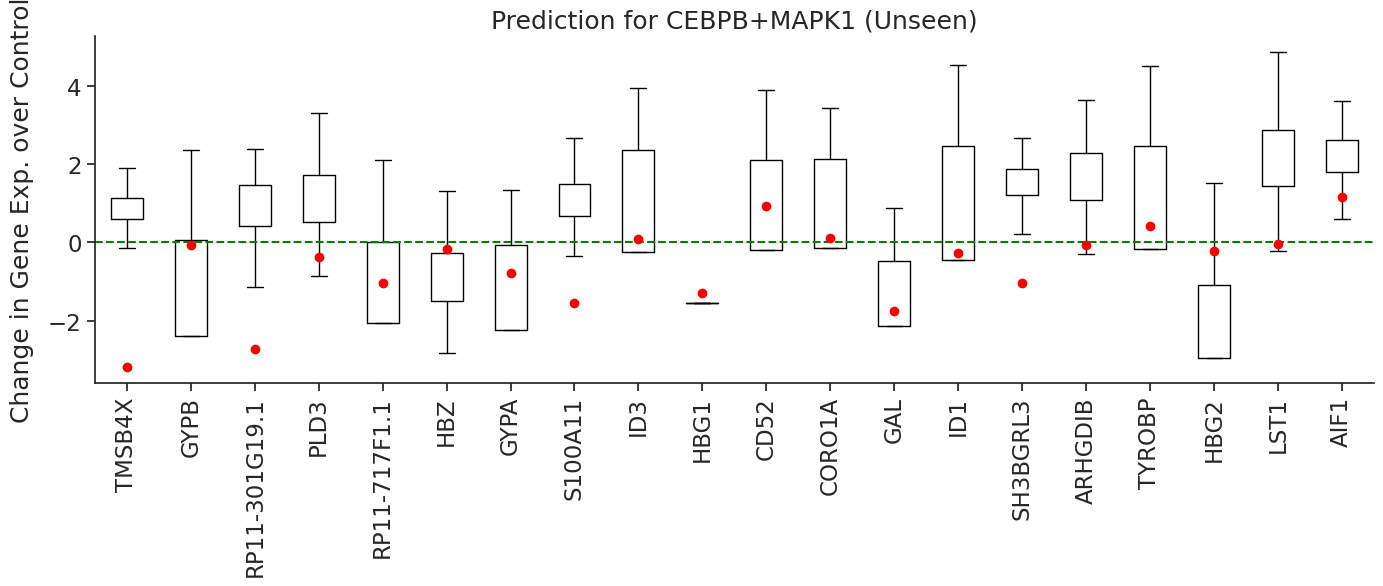

In [17]:
# --- 3. Identify Unseen Perturbations ---
train_conditions = set(adata[adata.obs['split'] == 'train'].obs['condition'].unique())
test_conditions = set(adata[adata.obs['split'] == 'test'].obs['condition'].unique())

# Unseen are conditions in test that NEVER appeared in train
unseen_perts = list(test_conditions - train_conditions)
print(f"Number of unseen perturbations: {len(unseen_perts)}")
if len(unseen_perts) > 0:
    print(f"Sample unseen: {unseen_perts[:5]}")

# --- 4. Refactored Plotting Function (No GEARS) ---
def plot_perturbation_native(model, query, adata, save_file=None, pool_size=100):
    sns.set_theme(style="ticks", rc={"axes.facecolor": (0, 0, 0, 0)}, font_scale=1.5)

    # Get differentially expressed genes for this specific perturbation
    # (Assuming you calculated DEGs or we just look at highly variable ones)
    ctrl_adata = adata[adata.obs["condition"] == "ctrl"].copy()
    
    # 1. Get true expression of perturbed cells
    truth_adata = adata[adata.obs["condition"] == query]
    if len(truth_adata) == 0:
        print(f"No cells found for condition {query}")
        return
        
    truth_expr = truth_adata.X.toarray() if hasattr(truth_adata.X, "toarray") else truth_adata.X
    
    # 2. Get predicted expression
    preds_dict = predict_perturbation(model, [query], ctrl_adata, pool_size=pool_size)
    pred_expr = preds_dict[query]
    
    # 3. Get control baseline means to calculate Delta (Change in expression)
    ctrl_expr = ctrl_adata.X.toarray() if hasattr(ctrl_adata.X, "toarray") else ctrl_adata.X
    ctrl_means = ctrl_expr.mean(axis=0)

    # Calculate Deltas
    truth_delta = truth_expr - ctrl_means
    pred_delta = pred_expr - ctrl_means

    # Let's plot the top 20 most changed genes in the truth dataset to keep the plot readable
    top_gene_indices = np.argsort(np.abs(truth_delta.mean(axis=0)))[-20:]
    genes_to_plot = adata.var_names[top_gene_indices]

    truth_plot = truth_delta[:, top_gene_indices]
    pred_plot = pred_delta[top_gene_indices]

    # Plotting
    fig, ax = plt.subplots(figsize=[16.5, 4.5])
    plt.title(f"Prediction for {query} (Unseen)")
    
    plt.boxplot(truth_plot, showfliers=False, medianprops=dict(linewidth=0))
    for i in range(len(pred_plot)):
        _ = plt.scatter(i + 1, pred_plot[i], color="red", zorder=5)

    plt.axhline(0, linestyle="dashed", color="green")
    ax.xaxis.set_ticklabels(genes_to_plot, rotation=90)
    plt.ylabel("Change in Gene Exp. over Control", labelpad=10)
    sns.despine()

    if save_file:
        fig.savefig(save_file, bbox_inches="tight", transparent=False)
    plt.show()

# Test it on an unseen perturbation!
if unseen_perts:
    query_pert = unseen_perts[0]
    print(f"Plotting: {query_pert}")
    plot_perturbation_native(
        model, 
        query=query_pert, 
        adata=adata, 
        pool_size=100,
        save_file=str(save_dir / f"test_eval_{query_pert}.png")
    )